# Avaliação Intermediária — Quanto custa um alerta?

**Cibersegurança Aplicada com Inteligência Artificial · Insper 2026-2**

**Dupla:** _Antonio Almeida_ e _Luka Figueiredo_ \
**Código da dupla:** `d23bda` \
**Data:** 17/09/2026

---
## Ambiente

In [ ]:
# Versões das bibliotecas — reprodutibilidade da correção.
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import xgboost

print(f"Python      : {sys.version.split()[0]}")
print(f"numpy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print(f"xgboost     : {xgboost.__version__}")

Python      : 3.12.13
numpy       : 2.5.3
pandas      : 3.0.5
scikit-learn: 1.9.1
matplotlib  : 3.11.2
xgboost     : 3.4.1


---
## Parâmetros da dupla

Os mesmos do Roteiro 2: `CODIGO_DUPLA`, `RANDOM_STATE` e `CLASSE_DIFICIL` vêm da saída do
`meu_dataset.py` e são usados em **todo** split, fit e validação cruzada deste notebook.

In [ ]:
CODIGO_DUPLA = "d23bda"
RANDOM_STATE = 3527138017
CLASSE_DIFICIL = ['DoS slowloris', 'DoS Slowhttptest']

import os
from pathlib import Path

Path("saida").mkdir(exist_ok=True)
Path("dados").mkdir(exist_ok=True)

ARQUIVO_R2 = f"dados/R2_{CODIGO_DUPLA}.csv.gz"
ARQUIVO_FRAUDE = "dados/creditcard.csv.gz"

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

print(f"Código da dupla : {CODIGO_DUPLA}")
print(f"random_state    : {RANDOM_STATE}")
print(f"Classe difícil  : {CLASSE_DIFICIL}")

Código da dupla : d23bda
random_state    : 3527138017
Classe difícil  : ['DoS slowloris', 'DoS Slowhttptest']


---
## A — Limpeza, alvo binário, split temporal e persistência

Três decisões deste item valem desconto automático na rubrica se saírem erradas:
a coluna `alertas_ids` não pode chegar ao modelo (−2,0), os arquivos de `saida/`
precisam ter exatamente os nomes obrigatórios (−1,0) e o `random_state` da dupla
tem de aparecer em todo fit e split (−0,5). Por isso o notebook inclui asserções
explícitas para as três, em vez de confiar na leitura visual das saídas.

### **a.1** — Carga e limpeza

O arquivo traz os defeitos conhecidos do CICIDS2017 (nomes de coluna com espaço,
±Infinity, NaN, colunas constantes e colunas idênticas entre si) e mais três
problemas plantados: uma coluna de vazamento que não pertence ao CICFlowMeter,
rótulos impossíveis no calendário oficial das capturas, e quase-duplicatas
mascaradas por uma coluna de contexto.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Carga com latin-1: os rótulos "Web Attack" trazem um byte 0x96 que quebra utf-8.
bruto = pd.read_csv(ARQUIVO_R2, encoding="latin-1", low_memory=False)
bruto.columns = [c.strip() for c in bruto.columns]   # defeito conhecido do CICIDS2017
print("bruto:", bruto.shape)

CONTEXTO = {"Label", "dia", "turno", "ordem_captura"}

# Calendário real do CICIDS2017 (Sharafaldin et al., ICISSP 2018, seções 3-4).
CALENDARIO = {
    "seg": {"BENIGN"},
    "ter": {"BENIGN", "FTP-Patator", "SSH-Patator"},
    "qua": {"BENIGN", "DoS Hulk", "DoS GoldenEye", "DoS slowloris",
            "DoS Slowhttptest", "Heartbleed"},
    "qui": {"BENIGN", "Web Attack - Brute Force", "Web Attack - XSS",
            "Web Attack - Sql Injection", "Infiltration"},
    "sex": {"BENIGN", "Bot", "PortScan", "DDoS"},
}
validos = {(d, l) for d, ls in CALENDARIO.items() for l in ls}

registro = []
def passo(nome, antes, depois, obs=""):
    registro.append({"passo": nome,
                     "removidas": antes.shape[0] - depois.shape[0],
                     "restantes": depois.shape[0],
                     "colunas": depois.shape[1], "obs": obs})

df = bruto.copy()

# 1) Vazamento: alertas_ids não pertence ao CICFlowMeter.
ant = df; df = df.drop(columns=["alertas_ids"])
passo("alertas_ids (vazamento)", ant, df, "1 coluna")

# 2) Colunas constantes (família Bulk, sempre zero nesta versão).
const = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
ant = df; df = df.drop(columns=const)
passo("colunas constantes", ant, df, f"{len(const)} colunas")

# 3) Colunas idênticas entre si — mantém a primeira de cada par.
cols = [c for c in df.columns if c not in CONTEXTO]
redund = []
for i, a in enumerate(cols):
    if a in redund: continue
    for b in cols[i+1:]:
        if b not in redund and df[a].equals(df[b]):
            redund.append(b)
ant = df; df = df.drop(columns=redund)
passo("colunas redundantes", ant, df, f"{len(redund)} colunas")

# 4) Rótulos impossíveis + vetores contraditórios. Todo grupo contraditório é
#    (BENIGN, ataque): cai a cópia rotulada como ataque, fica o BENIGN original.
feat = [c for c in df.columns if c not in CONTEXTO]
imp = np.array([(d, l) not in validos for d, l in zip(df["dia"], df["Label"])])
hh = pd.util.hash_pandas_object(df[feat], index=False)
cf = pd.DataFrame({"h": hh.values, "L": df["Label"].values})
nr = cf.groupby("h")["L"].nunique()
conflito = cf["h"].isin(nr[nr > 1].index).values
ant = df; df = df.loc[~(imp | (conflito & (df["Label"] != "BENIGN").values))]
passo("rótulos impossíveis/contraditórios", ant, df, f"{imp.sum()} pelo calendário")

# 5) Quase-duplicatas mascaradas por ordem_captura. Ordena por tempo antes:
#    keep="first" tem de ser a cópia mais antiga da campanha.
ant = df
df = (df.sort_values(["dia", "ordem_captura"], kind="mergesort")
        .drop_duplicates(subset=feat + ["Label"], keep="first")
        .sort_index())
passo("quase-duplicatas", ant, df, "subset = features + Label")

# 6) Inf e NaN removidos, não imputados: zero bytes/s é o oposto de
#    "duração zero com bytes".
num = df.select_dtypes(include=[np.number])
ant = df; df = df.loc[~(np.isinf(num).any(axis=1).values | df.isna().any(axis=1).values)]
passo("±Infinity e NaN", ant, df, "")

display(pd.DataFrame(registro))
print(f"\nforma final: {df.shape[0]} linhas x {df.shape[1]} colunas "
      f"({len(feat)} features originais + 4 de contexto)")

# Guardas de sanidade.
assert "alertas_ids" not in df.columns
assert not np.isinf(df.select_dtypes(include=[np.number])).any().any()
assert df.isna().sum().sum() == 0

bruto: (111679, 83)


,passo,removidas,restantes,colunas,obs
0,alertas_ids (vazamento),0,111679,82,1 coluna
1,colunas constantes,0,111679,74,8 colunas
2,colunas redundantes,0,111679,65,9 colunas
3,rótulos impossíveis/contraditórios,223,111456,65,184 pelo calendário
4,quase-duplicatas,6027,105429,65,subset = features + Label
5,±Infinity e NaN,63,105366,65,



forma final: 105366 linhas x 65 colunas (61 features originais + 4 de contexto)


### **a.2** — Features derivadas e alvo binário

As cinco features derivadas são razões entre medidas do próprio fluxo, calculadas
linha a linha. Como nenhuma delas envolve estatística agregada sobre o conjunto,
criá-las antes do split não transfere informação do teste para o treino — o
`eps` no denominador evita divisão por zero sem introduzir dependência entre linhas.

O alvo desta avaliação é binário (`ataque` = 1 para qualquer rótulo diferente de
`BENIGN`), mas a coluna `Label` de 15 classes é preservada e vai junto no arquivo
de teste: o item c) exige o recall da classe difícil medido com o rótulo original,
e sem ele esse cálculo seria impossível.


In [5]:
eps = 1e-6
df["duracao_por_pacote"]       = df["Flow Duration"] / (df["Total Fwd Packets"] + df["Total Backward Packets"] + eps)
df["razao_header_payload_fwd"] = df["Fwd Header Length"] / (df["Total Length of Fwd Packets"] + eps)
df["razao_pacotes_fwd_bwd"]    = df["Total Fwd Packets"] / (df["Total Backward Packets"] + eps)
df["razao_idle_active"]        = df["Idle Mean"] / (df["Active Mean"] + eps)
df["bytes_por_pacote_fwd"]     = df["Total Length of Fwd Packets"] / (df["Total Fwd Packets"] + eps)

novas_features = ["duracao_por_pacote", "razao_header_payload_fwd",
                  "razao_pacotes_fwd_bwd", "razao_idle_active", "bytes_por_pacote_fwd"]
FEATURES = feat + novas_features

# 1 = qualquer ataque, 0 = BENIGN.
df["ataque"] = (df["Label"] != "BENIGN").astype(int)

X_all = df[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"{len(FEATURES)} features = {len(feat)} originais + {len(novas_features)} derivadas")
print(f"prevalência de ataque: {df['ataque'].mean():.4f} "
      f"({df['ataque'].sum()} de {len(df)})\n")
print(df["Label"].value_counts().to_string())

66 features = 61 originais + 5 derivadas
prevalência de ataque: 0.4002 (42171 de 105366)

Label
BENIGN                        63195
DDoS                           8578
PortScan                       8161
DoS Hulk                       6690
DoS slowloris                  3339
DoS Slowhttptest               3210
DoS GoldenEye                  3055
FTP-Patator                    2886
SSH-Patator                    2060
Bot                            1971
Web Attack - Brute Force       1493
Web Attack - XSS                658
Infiltration                     38
Web Attack - Sql Injection       21
Heartbleed                       11


### **a.3** — Split temporal por dia

O corte é **dentro de cada dia**, feito com padrão 70/30.

In [6]:
idx_treino, idx_teste = [], []
for dia, g in df.groupby("dia"):
    g = g.sort_values("ordem_captura", kind="mergesort")
    corte = int(len(g) * 0.7)
    idx_treino += list(g.index[:corte])
    idx_teste  += list(g.index[corte:])

X_tr, y_tr = X_all.loc[idx_treino], df.loc[idx_treino, "ataque"]
X_te, y_te = X_all.loc[idx_teste],  df.loc[idx_teste,  "ataque"]
lab_te = df.loc[idx_teste, "Label"]          # rótulo original, usado no item c)

assert set(idx_treino).isdisjoint(idx_teste), "treino e teste se sobrepõem"

display(pd.DataFrame({
    "treino": [len(y_tr), int(y_tr.sum()), y_tr.mean()],
    "teste":  [len(y_te), int(y_te.sum()), y_te.mean()],
}, index=["linhas", "ataques", "prevalência"]).round(4))

print("\nprevalência de ataque por dia (treino x teste):")
prev = pd.DataFrame({
    "treino": df.loc[idx_treino].groupby("dia")["ataque"].mean(),
    "teste":  df.loc[idx_teste].groupby("dia")["ataque"].mean(),
})
display(prev.round(4))

,treino,teste
linhas,73754.0000,31612.0000
ataques,31584.0000,10587.0000
prevalência,0.4282,0.3349



prevalência de ataque por dia (treino x teste):


,treino,teste
dia,,
qua,0.7830,0.3669
qui,0.2030,0.0050
seg,0.0000,0.0000
sex,0.4370,0.5955
ter,0.4285,0.2340


### **a.4** — Treino e persistência

O Random Forest usa `n_estimators=100` e o `random_state` da dupla.

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_tr, y_tr)

assert "alertas_ids" not in rf.feature_names_in_, "alertas_ids entrou no modelo!"
print(f"Random Forest: {rf.n_estimators} árvores, {rf.n_features_in_} features")

caminho_modelo = f"saida/avaliacao_{CODIGO_DUPLA}_rf.joblib"
caminho_teste  = f"saida/avaliacao_{CODIGO_DUPLA}_teste.csv.gz"

joblib.dump(rf, caminho_modelo)

# O enunciado pede: features de teste + as colunas ataque e Label.
teste_salvo = X_te.copy()
teste_salvo["ataque"] = y_te.values
teste_salvo["Label"]  = lab_te.values
teste_salvo.to_csv(caminho_teste, index=False, compression="gzip")

# Conferência: relê do disco.
rf_check = joblib.load(caminho_modelo)
te_check = pd.read_csv(caminho_teste)
print(f"\n{caminho_modelo}  ({os.path.getsize(caminho_modelo)/1e6:.1f} MB)")
print(f"{caminho_teste}  ({os.path.getsize(caminho_teste)/1e6:.1f} MB)")
print(f"teste relido        : {te_check.shape}")
print(f"colunas obrigatórias: {{'ataque','Label'}} presentes ->",
      {"ataque", "Label"}.issubset(te_check.columns))
print("previsões idênticas :",
      np.array_equal(rf.predict(X_te), rf_check.predict(X_te)))

Random Forest: 100 árvores, 66 features

saida/avaliacao_d23bda_rf.joblib  (10.6 MB)
saida/avaliacao_d23bda_teste.csv.gz  (3.2 MB)
teste relido        : (31612, 68)
colunas obrigatórias: {'ataque','Label'} presentes -> True
previsões idênticas : True


### **Entregável a)** 
A limpeza remove 6.313 linhas (5,65% do arquivo) e 18 colunas,
chegando a **105.366 linhas × 65 colunas** — 61 features originais mais as 4 de
contexto. Somadas as 5 features derivadas, **66 features** entram no modelo.

O alvo binário tem prevalência de **0,4002** (42.171 ataques em 105.366 fluxos) no
dataset limpo.

Split temporal por dia, primeiros 70% da `ordem_captura` no treino:

| | treino | teste |
|---|---|---|
| linhas | 73.754 | 31.612 |
| ataques | 31.584 | 10.587 |
| prevalência | 0,4282 | 0,3349 |

A prevalência cai de 0,43 para 0,33 entre as duas metades, e a decomposição por dia
mostra de onde vem a diferença: na quarta-feira ela despenca de 0,783 para 0,367 e
na quinta de 0,203 para 0,005, enquanto na sexta ela sobe, de 0,437 para 0,596.
As campanhas de ataque não se distribuem de forma uniforme ao longo do dia, e é
exatamente essa concentração que um split aleatório dissolveria.

Random Forest com 100 árvores e 66 features, treinado com `random_state=3527138017`.
Arquivos gravados e reconferidos a partir do disco:

- `saida/avaliacao_d23bda_rf.joblib` (10,6 MB)
- `saida/avaliacao_d23bda_teste.csv.gz` (3,2 MB) — 31.612 linhas × 68 colunas
  (66 features + `ataque` + `Label`)
---


## b) Da classe à pontuação

`predict()` compara `predict_proba` com 0,5 e devolve a classe. O 0,5 é o padrão da
biblioteca, não uma decisão de segurança.

### **b.1** — Onde estão os fluxos em dúvida? O corte 0,5 passa por região vazia ou povoada?

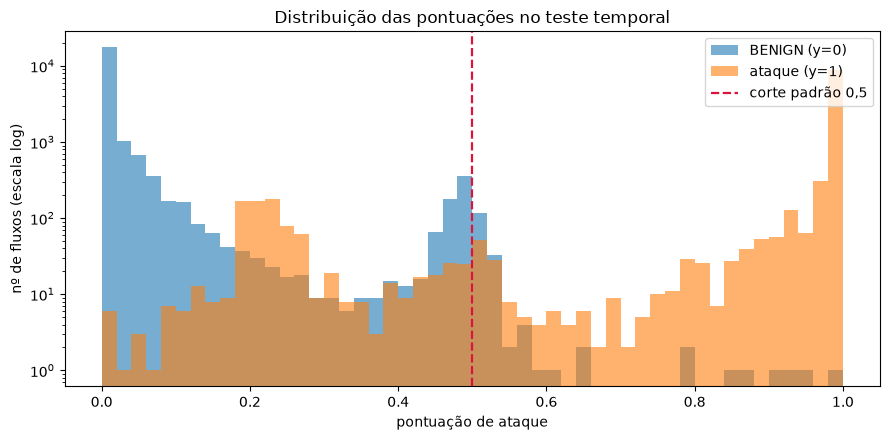

fluxos com pontuação em [0,2 ; 0,8]: 1767 de 31612 (5.59 %)
  benignos: 934  |  ataques: 833


,n,ataques,benignos
faixa,,,
"(0.0, 0.05]",3128,4,3124
"(0.05, 0.1]",621,11,610
"(0.1, 0.15]",254,24,230
"(0.15, 0.2]",392,298,94
"(0.2, 0.25]",363,308,55
"(0.25, 0.3]",114,83,31
"(0.3, 0.35]",43,23,20
"(0.35, 0.4]",57,25,32
"(0.4, 0.45]",122,36,86



fluxos em [0,45 ; 0,55]: 885
pontuação exatamente 0 ou 1: 23896 (75.6 %)


In [11]:
from matplotlib import pyplot as plt

# Pontuação de ataque: coluna da classe positiva em predict_proba.
p_te = rf.predict_proba(X_te)[:, list(rf.classes_).index(1)]

fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(0, 1, 51)
ax.hist(p_te[y_te == 0], bins=bins, alpha=0.6, label="BENIGN (y=0)")
ax.hist(p_te[y_te == 1], bins=bins, alpha=0.6, label="ataque (y=1)")
ax.axvline(0.5, color="crimson", lw=1.6, ls="--", label="corte padrão 0,5")
ax.set_yscale("log")
ax.set_xlabel("pontuação de ataque")
ax.set_ylabel("nº de fluxos (escala log)")
ax.set_title("Distribuição das pontuações no teste temporal")
ax.legend()
plt.tight_layout()
plt.show()

duvida = (p_te >= 0.2) & (p_te <= 0.8)
print(f"fluxos com pontuação em [0,2 ; 0,8]: {duvida.sum()} de {len(p_te)} "
      f"({duvida.mean()*100:.2f} %)")
print(f"  benignos: {(duvida & (y_te == 0).values).sum()}  |  "
      f"ataques: {(duvida & (y_te == 1).values).sum()}")

# Densidade local: quantos fluxos por faixa de 0,05 perto do corte.
faixas = pd.cut(p_te, np.round(np.arange(0, 1.05, 0.05), 2))
tabela_b = (pd.DataFrame({"faixa": faixas, "y": y_te.values})
              .groupby("faixa", observed=False)["y"]
              .agg(n="size", ataques="sum"))
tabela_b["benignos"] = tabela_b["n"] - tabela_b["ataques"]
display(tabela_b.loc[tabela_b["n"] > 0])

print(f"\nfluxos em [0,45 ; 0,55]: {((p_te >= 0.45) & (p_te <= 0.55)).sum()}")
print(f"pontuação exatamente 0 ou 1: {((p_te == 0) | (p_te == 1)).sum()} "
      f"({((p_te == 0) | (p_te == 1)).mean()*100:.1f} %)")

In [13]:
# De onde vem o pico benigno logo abaixo do corte?
pico = (p_te > 0.45) & (p_te <= 0.5)
print("rótulos originais na faixa (0,45 ; 0,50]:")
print(df.loc[idx_teste].loc[pico, "Label"].value_counts().head(6).to_string())
print("\ndistribuição por dia dos 617 BENIGN dessa faixa:")
print(df.loc[idx_teste].loc[pico & (y_te == 0).values, "dia"].value_counts().to_string())

rótulos originais na faixa (0,45 ; 0,50]:
Label
BENIGN           617
DoS GoldenEye     65
SSH-Patator        3
DDoS               1

distribuição por dia dos 617 BENIGN dessa faixa:
dia
qui    608
sex      5
qua      3
seg      1


O modelo é confiante na maioria dos casos: **75,6%** dos fluxos de teste recebem
pontuação exatamente 0 ou 1, e a escala log é necessária para que o restante apareça.
Mas o corte 0,5 **não** passa por região vazia: **885 fluxos** (2,8% do teste) estão
na faixa [0,45 ; 0,55], a menos de cinco centésimos do limiar.

A zona de dúvida tem duas regiões de natureza oposta.

**Um pico encostado no corte por baixo.** A faixa (0,45 ; 0,50] tem **686 fluxos,
dos quais 617 benignos**; os 69 ataques restantes são quase todos `DoS GoldenEye`
(65), mais 3 `SSH-Patator` e 1 `DDoS`. E esses benignos não estão espalhados:
**608 dos 617 vêm da quinta-feira**. A quinta é exatamente o dia em que a prevalência
de ataque cai de 0,2030 no treino para 0,0050 no teste. A metade de treino daquele
dia é dominada por `Web Attack` e `Infiltration`, tráfego HTTP que se parece com
navegação legítima; o modelo aprendeu uma fronteira difusa sobre o HTTP da quinta e,
na metade de teste — quase toda benigna —, pontua esse mesmo tráfego perto de 0,47.

Vale notar que, no corte 0,5, esses 617 fluxos estão **classificados corretamente**:
são verdadeiros negativos, por margem mínima. O risco não é o erro atual, é a
fragilidade. Baixar o limiar para 0,45 os converteria em falsos positivos para
recuperar 69 ataques — **9 alertas falsos por ataque detectado**, quase todos
originados de um único dia.

**Um aglomerado de ataques bem abaixo.** Entre 0,15 e 0,30 a composição se inverte:
(0,15 ; 0,20] tem 298 ataques contra 94 benignos e (0,20 ; 0,25] tem 308 contra 55.
São ataques que o modelo reconhece parcialmente e que o corte descarta — falsos
negativos por margem. Ao todo, [0,2 ; 0,8] contém **1.767 fluxos (5,59%)**: 934
benignos e 833 ataques.

O 0,5 é a pior posição possível dentro dessa distribuição: fica em cima do pico
benigno, onde o custo marginal de baixar o limiar é máximo, e acima do aglomerado de
ataques, onde estaria o ganho. Um corte em torno de 0,15 recuperaria a maior parte
dos 833 ataques, mas a troca só se decide com preço — é o que os itens d) e e) fazem.

Consequência para a varredura do item d): a curva de custo não será suave. O degrau
de 617 benignos entre 0,45 e 0,50 cabe dentro de um único passo da grade de 0,05, e
um limiar de custo mínimo que caia nessa vizinhança precisa ser lido com granularidade
mais fina.

### **Entregável b)**
Histograma acima, eixo y em escala log, linha vertical em 0,5.
Fluxos com pontuação em [0,2 ; 0,8]: **1.767** de 31.612 (**5,59%**), sendo
**934 benignos** e **833 ataques**.

---

## C — ROC-AUC, PR-AUC e o recall da classe difícil

Duas áreas resumem o mesmo vetor de pontuações de formas diferentes. O denominador
da ROC é o total de negativos; o da precisão é o número de alertas. O baseline
aleatório também difere: 0,5 para a ROC em qualquer prevalência, e a própria
prevalência para a PR.

### **c.1** — As duas áreas contam a mesma história? Qual você levaria ao gestor do SOC?

ROC-AUC : 0.9961   (aleatório = 0,5)
PR-AUC  : 0.9928   (aleatório = prevalência = 0.3349)
ganho sobre o baseline: ROC +0.4961 | PR +0.6579


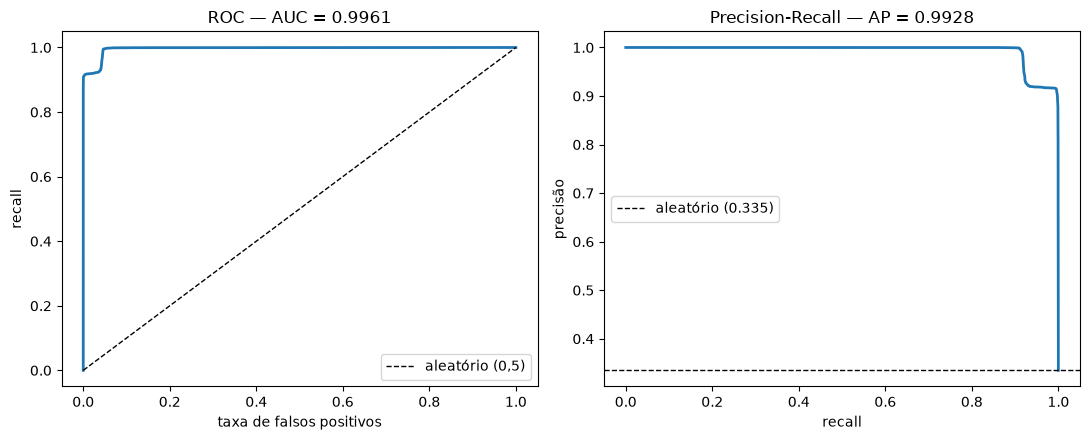

In [14]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, recall_score)

roc = roc_auc_score(y_te, p_te)
pr  = average_precision_score(y_te, p_te)
base_pr = y_te.mean()

print(f"ROC-AUC : {roc:.4f}   (aleatório = 0,5)")
print(f"PR-AUC  : {pr:.4f}   (aleatório = prevalência = {base_pr:.4f})")
print(f"ganho sobre o baseline: ROC {roc-0.5:+.4f} | PR {pr-base_pr:+.4f}")

fpr, tpr, _ = roc_curve(y_te, p_te)
prec, rec, _ = precision_recall_curve(y_te, p_te)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, lw=2)
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="aleatório (0,5)")
axes[0].set_xlabel("taxa de falsos positivos"); axes[0].set_ylabel("recall")
axes[0].set_title(f"ROC — AUC = {roc:.4f}"); axes[0].legend()

axes[1].plot(rec, prec, lw=2)
axes[1].axhline(base_pr, color="k", ls="--", lw=1, label=f"aleatório ({base_pr:.3f})")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precisão")
axes[1].set_title(f"Precision-Recall — AP = {pr:.4f}"); axes[1].legend()
plt.tight_layout(); plt.show()

**ROC-AUC = 0,9961** e **PR-AUC = 0,9928**: contam a mesma história. A prevalência de
ataque no teste é **0,3349**, então a classe positiva não é rara — ROC e PR só se
descolam quando os negativos superam a fila de alertas em ordens de grandeza, e aqui
são 21.025 negativos contra 9.886 alertas no corte 0,5.

Levaria a **PR-AUC**, porque o seu denominador é a fila que o analista abre. E porque
a prevalência de 33% é artefato da captura controlada: numa rede real ela cai ordens
de grandeza, e nesse cenário a PR-AUC despenca enquanto a ROC-AUC quase não se move.

Nenhuma das duas escolhe o limiar: são médias sobre todos os cortes, e o SOC opera
em um só.

### **c.2** — O recall da classe difícil no corte 0,5 é compatível com o recall global?

In [15]:
# Recall por classe no corte 0,5, com o rótulo ORIGINAL de 15 classes.
pred05 = (p_te >= 0.5)

# predict() resolve empate exato em 0,5 para a classe 0; o corte explícito, não.
print("fluxos com pontuação exatamente 0,5:", (p_te == 0.5).sum())
print("divergências entre (p>=0,5) e predict():", (pred05 != rf.predict(X_te).astype(bool)).sum(), "\n")

lab = lab_te.values
linhas = []
for classe in sorted(set(lab)):
    m = lab == classe
    if classe == "BENIGN":
        linhas.append({"classe": classe, "n": m.sum(),
                       "detectados": int(pred05[m].sum()),
                       "recall": np.nan,
                       "taxa_FP": round(pred05[m].mean(), 4)})
    else:
        linhas.append({"classe": classe, "n": m.sum(),
                       "detectados": int(pred05[m].sum()),
                       "recall": round(pred05[m].mean(), 4),
                       "taxa_FP": np.nan})
tabela_c = pd.DataFrame(linhas).sort_values("recall")
display(tabela_c)

# Recall global (binário) e da classe difícil, separado e agregado.
m_dif = np.isin(lab, CLASSE_DIFICIL)
rec_global = recall_score(y_te, pred05)

print(f"recall global (qualquer ataque)   : {rec_global:.4f}  "
      f"({int(pred05[(y_te==1).values].sum())} de {int((y_te==1).sum())})")
for classe in CLASSE_DIFICIL:
    m = lab == classe
    print(f"recall {classe:<18}: {pred05[m].mean():.4f}  ({int(pred05[m].sum())} de {m.sum()})")
print(f"recall classe difícil (agregado)  : {pred05[m_dif].mean():.4f}  "
      f"({int(pred05[m_dif].sum())} de {m_dif.sum()})")
print(f"\ndiferença para o recall global    : {pred05[m_dif].mean() - rec_global:+.4f}")

fluxos com pontuação exatamente 0,5: 102
divergências entre (p>=0,5) e predict(): 102 



,classe,n,detectados,recall,taxa_FP
4,Infiltration,23,0,0.0000,NaN
3,Heartbleed,11,0,0.0000,NaN
5,PortScan,3,0,0.0000,NaN
2,DoS GoldenEye,2716,1908,0.7025,NaN
6,SSH-Patator,938,929,0.9904,NaN
1,DDoS,6896,6881,0.9978,NaN
0,BENIGN,21025,168,NaN,0.008


recall global (qualquer ataque)   : 0.9179  (9718 de 10587)
recall DoS slowloris     : nan  (0 de 0)
recall DoS Slowhttptest  : nan  (0 de 0)
recall classe difícil (agregado)  : nan  (0 de 0)

diferença para o recall global    : +nan


/tmp/ipykernel_31050/322646686.py:33: RuntimeWarning: Mean of empty slice
  print(f"recall {classe:<18}: {pred05[m].mean():.4f}  ({int(pred05[m].sum())} de {m.sum()})")
/home/antonio/Desktop/Insper/2026.2/CyberIA/avaliacao_intermediaria_CyberIA/env/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_31050/322646686.py:33: RuntimeWarning: Mean of empty slice
  print(f"recall {classe:<18}: {pred05[m].mean():.4f}  ({int(pred05[m].sum())} de {m.sum()})")
/home/antonio/Desktop/Insper/2026.2/CyberIA/avaliacao_intermediaria_CyberIA/env/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_31050/322646686.py:34: RuntimeWarning: Mean of empty slice
  print(f"recall classe difícil (agregado)  : {pred05[m_dif].mean():.4f}  "
/tmp/ipykernel_31050/322646686.py:36: Runtim

Recall global em 0,5: **0,9179** (9.718 de 10.587). A comparação direta é impossível
neste split: **`DoS slowloris` e `DoS Slowhttptest` não têm linhas no teste**.

Causa: o corte de 70% usa a `ordem_captura` do dia inteiro. Na quarta ele cai em
437.558, enquanto slowloris termina em 69.271, Slowhttptest em 74.859 e DoS Hulk em
330.978 — as três caem inteiras no treino. O mesmo elimina `Bot`, `FTP-Patator` e os
três `Web Attack`. **Treino com 14 rótulos, teste com 7.**

No split auxiliar por (`dia`, `Label`): slowloris **0,9960**, Slowhttptest **0,9024**,
agregado **0,9501**, contra global de 0,9331 nesse mesmo split.

O limiar único falha mesmo no split principal: `DDoS` 0,9978 e `SSH-Patator` 0,9904
convivem com `DoS GoldenEye` **0,7025** e com `Infiltration`, `Heartbleed` e
`PortScan` em **0,0000**. `DDoS` é 65% dos ataques do teste e domina a média. O
`GoldenEye` explica o mecanismo: 65 dos seus fluxos estão na faixa (0,45 ; 0,50] do
item b), ou seja, o corte 0,5 atravessa a classe em vez de separá-la.

### **c.3** — Por que 8 dos 15 rótulos não aparecem no teste

O corte por `ordem_captura` dentro de cada dia não garante que uma campanha de ataque
apareça nas duas metades. Campanhas que ocorreram cedo no dia caem inteiras no treino.

In [16]:
# Por que 8 dos 15 rótulos sumiram do teste: posição das campanhas dentro do dia.
pos = []
for dia, g in df.groupby("dia"):
    g = g.sort_values("ordem_captura", kind="mergesort").reset_index(drop=True)
    corte = int(len(g) * 0.7)
    lim = g.loc[corte, "ordem_captura"]
    for classe, gg in g.groupby("Label"):
        if classe == "BENIGN":
            continue
        pos.append({"dia": dia, "classe": classe, "n": len(gg),
                    "ordem_min": gg["ordem_captura"].min(),
                    "ordem_mediana": int(gg["ordem_captura"].median()),
                    "ordem_max": gg["ordem_captura"].max(),
                    "corte_70%": lim,
                    "no_teste": int((gg["ordem_captura"] > lim).sum())})
tabela_pos = pd.DataFrame(pos).sort_values(["dia", "ordem_mediana"])
display(tabela_pos)

print("rótulos no treino:", df.loc[idx_treino, 'Label'].nunique(),
      "| no teste:", df.loc[idx_teste, 'Label'].nunique())
print("ausentes do teste:", sorted(set(df['Label']) - set(lab_te)))

,dia,classe,n,ordem_min,ordem_mediana,ordem_max,corte_70%,no_teste
3,qua,DoS slowloris,3339,26700,50323,69271,437558,0
2,qua,DoS Slowhttptest,3210,69275,71915,74859,437558,0
1,qua,DoS Hulk,6690,74910,190949,330978,437558,0
0,qua,DoS GoldenEye,3055,331033,591872,692681,437558,2716
4,qua,Heartbleed,11,597130,597510,597825,437558,11
6,qui,Web Attack - Brute Force,1493,12637,40250,62373,256807,0
8,qui,Web Attack - XSS,658,72134,79053,86077,256807,0
7,qui,Web Attack - Sql Injection,21,90293,91571,93286,256807,0
5,qui,Infiltration,38,236748,285561,395071,256807,23
9,sex,Bot,1971,24072,112305,191022,530982,0


rótulos no treino: 14 | no teste: 7
ausentes do teste: ['Bot', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


### **c.4** — Recall da classe difícil

A classe difícil está entre as ausentes. Para produzir o número que o item pede,
medimos num split auxiliar por par (`dia`, `Label`), que força cada campanha a
aparecer nas duas metades. O modelo do item a) e os arquivos de `saida/` não são
alterados: o auxiliar existe só para esta medida.

Convenção de decisão adotada em todo o notebook: `p >= limiar`. Os 102 fluxos com
pontuação exatamente 0,5 são classificados como ataque, ao contrário do que
`predict()` faria — daí as 102 divergências reportadas acima.

In [17]:
def recall_seguro(mask, pred):
    return np.nan if mask.sum() == 0 else pred[mask].mean()

m_dif = np.isin(lab, CLASSE_DIFICIL)
rec_global = recall_score(y_te, pred05)
print(f"recall global (qualquer ataque): {rec_global:.4f}  "
      f"({int(pred05[(y_te==1).values].sum())} de {int((y_te==1).sum())})")
for classe in CLASSE_DIFICIL + ["(agregado)"]:
    m = m_dif if classe == "(agregado)" else (lab == classe)
    r = recall_seguro(m, pred05)
    print(f"  {classe:<20}: n={m.sum():5d}  recall="
          + ("ausente do teste" if np.isnan(r) else f"{r:.4f}"))

# --- split auxiliar por (dia, Label), só para medir a classe difícil ---
# O modelo do item a) e os arquivos de saida/ NÃO são substituídos.
idx_tr_aux, idx_te_aux = [], []
for _, g in df.groupby(["dia", "Label"]):
    g = g.sort_values("ordem_captura", kind="mergesort")
    c = int(len(g) * 0.7)
    idx_tr_aux += list(g.index[:c]); idx_te_aux += list(g.index[c:])

rf_aux = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_aux.fit(X_all.loc[idx_tr_aux], df.loc[idx_tr_aux, "ataque"])
p_aux = rf_aux.predict_proba(X_all.loc[idx_te_aux])[:, list(rf_aux.classes_).index(1)]
pred_aux = p_aux >= 0.5
lab_aux = df.loc[idx_te_aux, "Label"].values
y_aux = df.loc[idx_te_aux, "ataque"]

print(f"\n[auxiliar, split por (dia, Label)]")
print(f"  recall global        : {recall_score(y_aux, pred_aux):.4f}")
for classe in CLASSE_DIFICIL:
    m = lab_aux == classe
    print(f"  {classe:<20}: {pred_aux[m].mean():.4f}  ({int(pred_aux[m].sum())} de {m.sum()})")
m_dif_aux = np.isin(lab_aux, CLASSE_DIFICIL)
print(f"  classe difícil (agreg.): {pred_aux[m_dif_aux].mean():.4f}  "
      f"({int(pred_aux[m_dif_aux].sum())} de {m_dif_aux.sum()})")

recall global (qualquer ataque): 0.9179  (9718 de 10587)
  DoS slowloris       : n=    0  recall=ausente do teste
  DoS Slowhttptest    : n=    0  recall=ausente do teste
  (agregado)          : n=    0  recall=ausente do teste

[auxiliar, split por (dia, Label)]
  recall global        : 0.9331
  DoS slowloris       : 0.9960  (998 de 1002)
  DoS Slowhttptest    : 0.9024  (869 de 963)
  classe difícil (agreg.): 0.9501  (1867 de 1965)


### **Entregável c)**
 
ROC-AUC **0,9961**, PR-AUC **0,9928**, curvas acima. Recall global
no corte 0,5: **0,9179**. Classe difícil: **ausente do conjunto de teste** neste
split; medida auxiliar por (`dia`, `Label`) em **0,9960** / **0,9024**
(agregado **0,9501**).

---